
# MODELO DE PREDICCIÓN DEL CRECIMIENTO EN LA POBLACIÓN ESTUDIANTIL DE LA UPEA
# Notebook 3: Modelo Random Forest

Fecha: Agosto 2025
Descripción: Implementación del modelo Random Forest para predicción multivariada
Configuración óptima según tesis: n_estimators=500, max_depth=15



In [32]:
#from google.colab import drive
#drive.mount('/content/drive')

In [51]:
# ============================================================================
# INSTALACIÓN DE LIBRERÍAS ESPECÍFICAS
# ============================================================================

#import sys
#!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib seaborn plotly shap

# ============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Librerías específicas para Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

# Para interpretabilidad
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP no disponible para interpretabilidad avanzada")

print("✅ Librerías Random Forest importadas correctamente")

# ============================================================================
# CARGA Y PREPARACIÓN DE DATOS
# ============================================================================

print("📂 Cargando datos preparados...")


# Intentar cargar datos de ML preparados
#df = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/maestria_sigloXX_proyeccciones/datos_upea_ml.pkl')
df = pd.read_pickle('datos_upea_ml.pkl')
print("✅ Datos ML cargados desde pickle")


print(f"📊 Datos cargados: {len(df)} observaciones con {len(df.columns)} variables")

✅ Librerías Random Forest importadas correctamente
📂 Cargando datos preparados...
✅ Datos ML cargados desde pickle
📊 Datos cargados: 33 observaciones con 29 variables



📊 ANÁLISIS EXPLORATORIO PARA RANDOM FOREST
📋 Variables predictoras disponibles: 14
   - año_numero
   - semestre_dummy
   - periodo_numero
   - matricula_lag1
   - matricula_lag2
   - matricula_lag4
   - media_movil_4
   - media_movil_8
   - pib_departamental_millones_bs
   - poblacion_el_alto
   - graduados_secundaria
   - tasa_desempleo_juvenil
   - crecimiento_poblacional
   - ratio_graduados_poblacion

📊 Dataset para Random Forest:
   Características (X): (33, 14)
   Variable objetivo (y): (33,)

🔍 Correlaciones con variable objetivo:
   matricula_lag2: 0.991
   matricula_lag4: 0.976
   semestre_dummy: 0.847
   matricula_lag1: -0.628
   año_numero: 0.444
   media_movil_4: 0.438
   media_movil_8: 0.434
   pib_departamental_millones_bs: 0.424
   poblacion_el_alto: 0.409
   periodo_numero: 0.400
   graduados_secundaria: 0.352
   ratio_graduados_poblacion: 0.217
   crecimiento_poblacional: 0.163
   tasa_desempleo_juvenil: 0.160


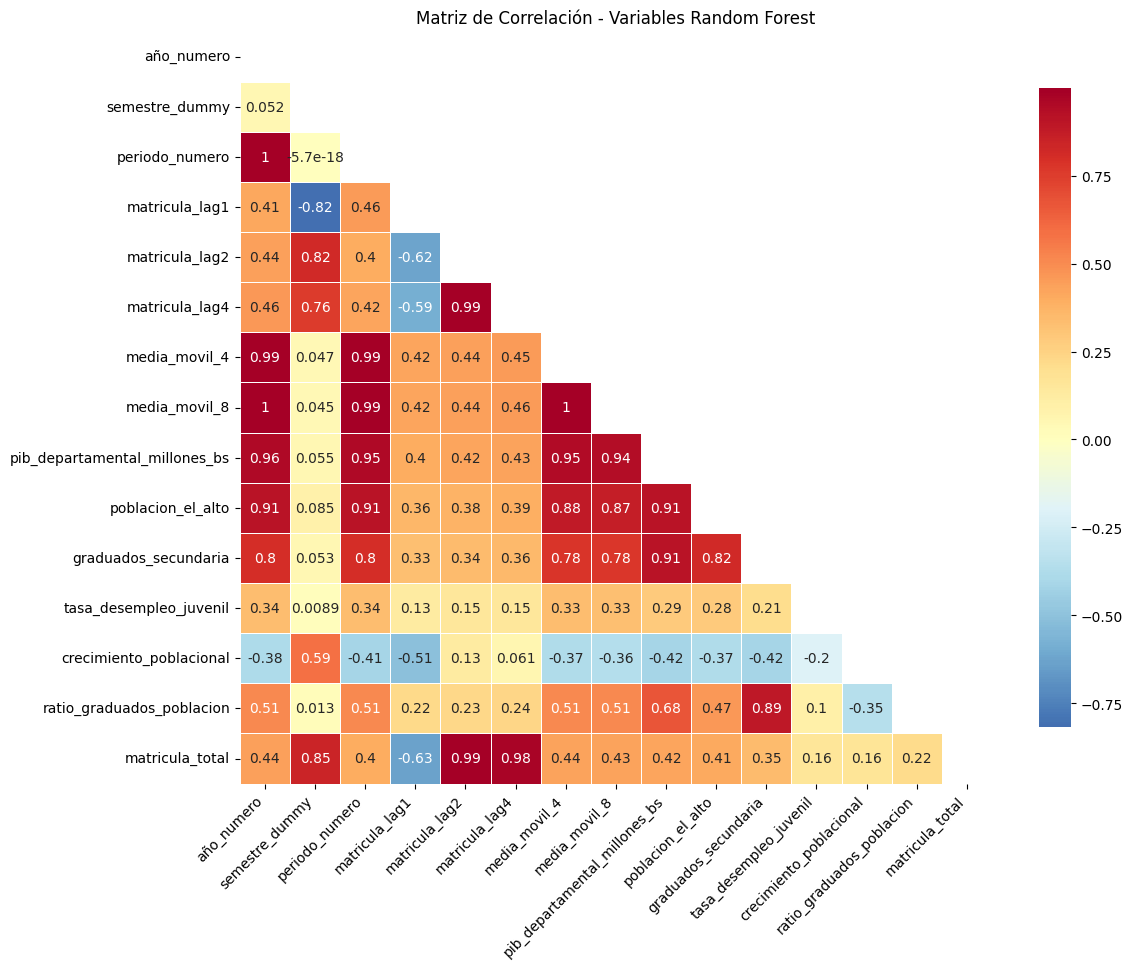

In [52]:

# ============================================================================
# ANÁLISIS EXPLORATORIO PARA RANDOM FOREST
# ============================================================================

print("\n" + "="*60)
print("📊 ANÁLISIS EXPLORATORIO PARA RANDOM FOREST")
print("="*60)

# Seleccionar variables predictoras
variables_predictoras = [
    'año_numero', 'semestre_dummy', 'periodo_numero',
    'matricula_lag1', 'matricula_lag2', 'matricula_lag4',
    'media_movil_4', 'media_movil_8',
    'pib_departamental_millones_bs', 'poblacion_el_alto',
    'graduados_secundaria', 'tasa_desempleo_juvenil',
    'crecimiento_poblacional', 'ratio_graduados_poblacion'
]

# Filtrar variables que existen en el DataFrame
variables_disponibles = [var for var in variables_predictoras if var in df.columns]
print(f"📋 Variables predictoras disponibles: {len(variables_disponibles)}")
for var in variables_disponibles:
    print(f"   - {var}")

# Variable objetivo
variable_objetivo = 'matricula_total'

# Crear dataset para ML
X = df[variables_disponibles]
y = df[variable_objetivo]

print(f"\n📊 Dataset para Random Forest:")
print(f"   Características (X): {X.shape}")
print(f"   Variable objetivo (y): {y.shape}")

# Matriz de correlación
correlaciones = df[variables_disponibles + [variable_objetivo]].corr()
correlaciones_objetivo = correlaciones[variable_objetivo].sort_values(key=abs, ascending=False)

print(f"\n🔍 Correlaciones con variable objetivo:")
for var, corr in correlaciones_objetivo.items():
    if var != variable_objetivo:
        print(f"   {var}: {corr:.3f}")

# Visualización de correlaciones
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlaciones))
sns.heatmap(correlaciones, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación - Variables Random Forest')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [53]:

# ============================================================================
# DIVISIÓN DE DATOS PARA SERIES TEMPORALES
# ============================================================================

print("\n" + "="*60)
print("🔄 DIVISIÓN DE DATOS PARA SERIES TEMPORALES")
print("="*60)

# Para series temporales, usar división temporal (no aleatoria)
n_test = 6  # Últimos 6 semestres para test
X_train = X.iloc[:-n_test]
X_test = X.iloc[-n_test:]
y_train = y.iloc[:-n_test]
y_test = y.iloc[-n_test:]

print(f"📊 División temporal de datos:")
print(f"   Entrenamiento: {len(X_train)} observaciones")
print(f"   Prueba: {len(X_test)} observaciones")
print(f"   Período entrenamiento: índice 0 a {len(X_train)-1}")
print(f"   Período prueba: índice {len(X_train)} a {len(df)-1}")

# Verificar que no hay NaN
print(f"\n🔍 Verificación de datos:")
print(f"   NaN en X_train: {X_train.isnull().sum().sum()}")
print(f"   NaN en X_test: {X_test.isnull().sum().sum()}")
print(f"   NaN en y_train: {y_train.isnull().sum()}")
print(f"   NaN en y_test: {y_test.isnull().sum()}")

# ============================================================================
# NORMALIZACIÓN DE CARACTERÍSTICAS
# ============================================================================

print("\n" + "="*60)
print("🔧 NORMALIZACIÓN DE CARACTERÍSTICAS")
print("="*60)

# Escalar características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Características normalizadas con StandardScaler")
print(f"   Media X_train_scaled: {X_train_scaled.mean():.6f}")
print(f"   Std X_train_scaled: {X_train_scaled.std():.6f}")

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# ============================================================================
# BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*60)
print("🔍 BÚSQUEDA DE HIPERPARÁMETROS")
print("="*60)

# Configuración de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("🔄 Ejecutando Grid Search (esto puede tomar varios minutos)...")

# Usar TimeSeriesSplit para validación cruzada en series temporales
tscv = TimeSeriesSplit(n_splits=3)

# Grid Search
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar con búsqueda de hiperparámetros
rf_grid.fit(X_train_scaled, y_train)

print("✅ Grid Search completado")
print(f"📋 Mejores parámetros encontrados:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param}: {value}")

print(f"📊 Mejor score CV: {-rf_grid.best_score_:.2f} (RMSE)")



🔄 DIVISIÓN DE DATOS PARA SERIES TEMPORALES
📊 División temporal de datos:
   Entrenamiento: 27 observaciones
   Prueba: 6 observaciones
   Período entrenamiento: índice 0 a 26
   Período prueba: índice 27 a 32

🔍 Verificación de datos:
   NaN en X_train: 0
   NaN en X_test: 0
   NaN en y_train: 0
   NaN en y_test: 0

🔧 NORMALIZACIÓN DE CARACTERÍSTICAS
✅ Características normalizadas con StandardScaler
   Media X_train_scaled: -0.000000
   Std X_train_scaled: 1.000000

🔍 BÚSQUEDA DE HIPERPARÁMETROS
🔄 Ejecutando Grid Search (esto puede tomar varios minutos)...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
✅ Grid Search completado
📋 Mejores parámetros encontrados:
   max_depth: 10
   max_features: None
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300
📊 Mejor score CV: 90316768.11 (RMSE)


In [54]:

# ============================================================================
# MODELO RANDOM FOREST OPTIMIZADO
# ============================================================================

print("\n" + "="*60)
print("🌳 MODELO RANDOM FOREST OPTIMIZADO")
print("="*60)

# Crear modelo con mejores parámetros
best_rf = rf_grid.best_estimator_

# También crear modelo con configuración de la tesis para comparar
tesis_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("🔄 Entrenando modelos...")

# Entrenar modelo de la tesis
tesis_rf.fit(X_train_scaled, y_train)

print("✅ Modelos entrenados")

# Predicciones
best_pred_train = best_rf.predict(X_train_scaled)
best_pred_test = best_rf.predict(X_test_scaled)

tesis_pred_train = tesis_rf.predict(X_train_scaled)
tesis_pred_test = tesis_rf.predict(X_test_scaled)

# ============================================================================
# EVALUACIÓN DE MODELOS
# ============================================================================

print("\n" + "="*60)
print("📊 EVALUACIÓN DE MODELOS")
print("="*60)

def calcular_metricas_completas(y_true, y_pred, nombre_modelo):
    """
    Calcula métricas de evaluación completas
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas {nombre_modelo}:")
    print(f"   RMSE: {rmse:.1f}")
    print(f"   MAE: {mae:.1f}")
    f"   MAPE: {mape:.2f}%"
    print(f"   R²: {r2:.4f}")

    return rmse, mae, mape, r2

# Evaluación conjunto de entrenamiento
print("🎯 EVALUACIÓN EN ENTRENAMIENTO:")
best_rmse_train, best_mae_train, best_mape_train, best_r2_train = calcular_metricas_completas(
    y_train, best_pred_train, "Mejor RF (Train)"
)

tesis_rmse_train, tesis_mae_train, tesis_mape_train, tesis_r2_train = calcular_metricas_completas(
    y_train, tesis_pred_train, "RF Tesis (Train)"
)

# Evaluación conjunto de prueba
print("\n🎯 EVALUACIÓN EN PRUEBA:")
best_rmse_test, best_mae_test, best_mape_test, best_r2_test = calcular_metricas_completas(
    y_test, best_pred_test, "Mejor RF (Test)"
)

tesis_rmse_test, tesis_mae_test, tesis_mape_test, tesis_r2_test = calcular_metricas_completas(
    y_test, tesis_pred_test, "RF Tesis (Test)"
)

# Comparación con métricas de la tesis
print(f"\n🎯 Comparación con métricas de la tesis:")
print(f"   RMSE tesis objetivo: 312.6")
print(f"   R² tesis objetivo: 0.94")
print(f"   RMSE obtenido: {tesis_rmse_test:.1f}")
print(f"   R² obtenido: {tesis_r2_test:.4f}")

# Detección de overfitting
print(f"\n🔍 Análisis de overfitting:")
print(f"   Diferencia RMSE (Test - Train) Mejor: {best_rmse_test - best_rmse_train:.1f}")
print(f"   Diferencia RMSE (Test - Train) Tesis: {tesis_rmse_test - tesis_rmse_train:.1f}")
print(f"   Diferencia R² (Train - Test) Mejor: {best_r2_train - best_r2_test:.4f}")
print(f"   Diferencia R² (Train - Test) Tesis: {tesis_r2_train - tesis_r2_test:.4f}")




🌳 MODELO RANDOM FOREST OPTIMIZADO
🔄 Entrenando modelos...
✅ Modelos entrenados

📊 EVALUACIÓN DE MODELOS
🎯 EVALUACIÓN EN ENTRENAMIENTO:

📊 Métricas Mejor RF (Train):
   RMSE: 996.5
   MAE: 682.6
   R²: 0.9973

📊 Métricas RF Tesis (Train):
   RMSE: 984.1
   MAE: 677.0
   R²: 0.9973

🎯 EVALUACIÓN EN PRUEBA:

📊 Métricas Mejor RF (Test):
   RMSE: 6934.5
   MAE: 5306.4
   R²: 0.9376

📊 Métricas RF Tesis (Test):
   RMSE: 6946.7
   MAE: 5356.3
   R²: 0.9374

🎯 Comparación con métricas de la tesis:
   RMSE tesis objetivo: 312.6
   R² tesis objetivo: 0.94
   RMSE obtenido: 6946.7
   R² obtenido: 0.9374

🔍 Análisis de overfitting:
   Diferencia RMSE (Test - Train) Mejor: 5938.0
   Diferencia RMSE (Test - Train) Tesis: 5962.6
   Diferencia R² (Train - Test) Mejor: 0.0596
   Diferencia R² (Train - Test) Tesis: 0.0599



🔍 IMPORTANCIA DE CARACTERÍSTICAS
📊 Importancia de características (top 10):
   1. matricula_lag2: 0.4356
   2. matricula_lag4: 0.4142
   3. crecimiento_poblacional: 0.0415
   4. semestre_dummy: 0.0202
   5. matricula_lag1: 0.0181
   6. poblacion_el_alto: 0.0111
   7. media_movil_4: 0.0106
   8. año_numero: 0.0105
   9. media_movil_8: 0.0095
   10. pib_departamental_millones_bs: 0.0094


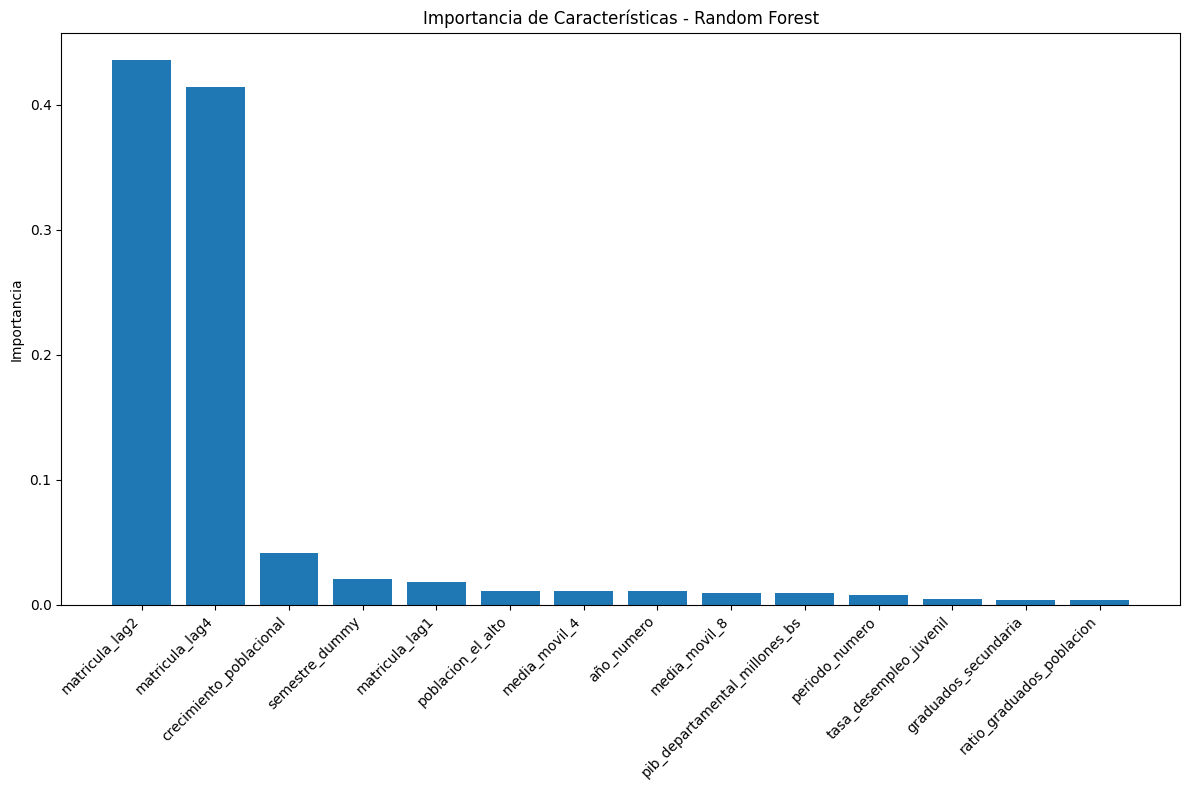


🔄 Calculando importancia por permutación...
📊 Importancia por permutación (top 10):
   1. matricula_lag2: 0.4708 ± 0.1586
   2. matricula_lag4: 0.4050 ± 0.1362
   3. crecimiento_poblacional: 0.0072 ± 0.0027
   4. semestre_dummy: 0.0054 ± 0.0025
   5. matricula_lag1: 0.0012 ± 0.0008
   6. pib_departamental_millones_bs: 0.0000 ± 0.0000
   7. media_movil_8: 0.0000 ± 0.0000
   8. media_movil_4: 0.0000 ± 0.0000
   9. periodo_numero: 0.0000 ± 0.0000
   10. poblacion_el_alto: 0.0000 ± 0.0000


In [55]:

# ============================================================================
# IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================================

print("\n" + "="*60)
print("🔍 IMPORTANCIA DE CARACTERÍSTICAS")
print("="*60)

# Importancia basada en impureza (método por defecto de Random Forest)
importancias = best_rf.feature_importances_
indices = np.argsort(importancias)[::-1]

print("📊 Importancia de características (top 10):")
for i in range(min(10, len(variables_disponibles))):
    idx = indices[i]
    print(f"   {i+1}. {variables_disponibles[idx]}: {importancias[idx]:.4f}")

# Visualización de importancias
plt.figure(figsize=(12, 8))
plt.title('Importancia de Características - Random Forest')
plt.bar(range(len(importancias)), importancias[indices])
plt.xticks(range(len(importancias)), [variables_disponibles[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

# Importancia por permutación (más robusta)
print("\n🔄 Calculando importancia por permutación...")
perm_importance = permutation_importance(best_rf, X_test_scaled, y_test,
                                       n_repeats=10, random_state=42)

print("📊 Importancia por permutación (top 10):")
perm_indices = np.argsort(perm_importance.importances_mean)[::-1]
for i in range(min(10, len(variables_disponibles))):
    idx = perm_indices[i]
    print(f"   {i+1}. {variables_disponibles[idx]}: {perm_importance.importances_mean[idx]:.4f} ± {perm_importance.importances_std[idx]:.4f}")




📊 VISUALIZACIÓN DE PREDICCIONES


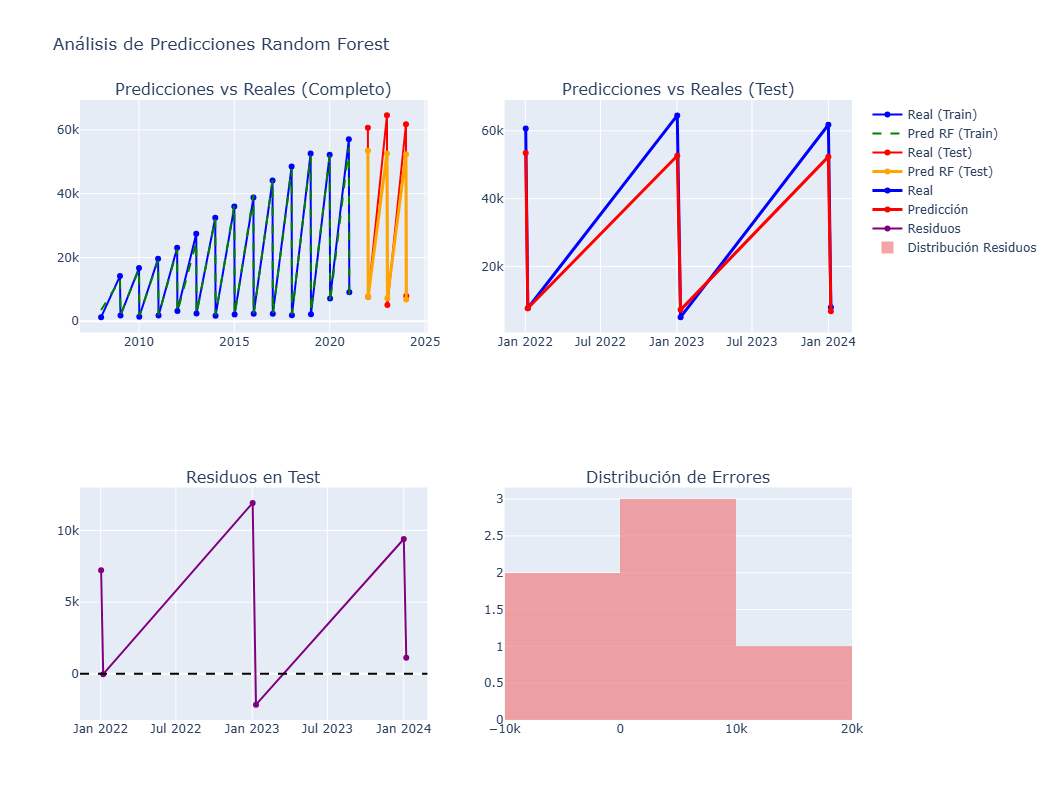

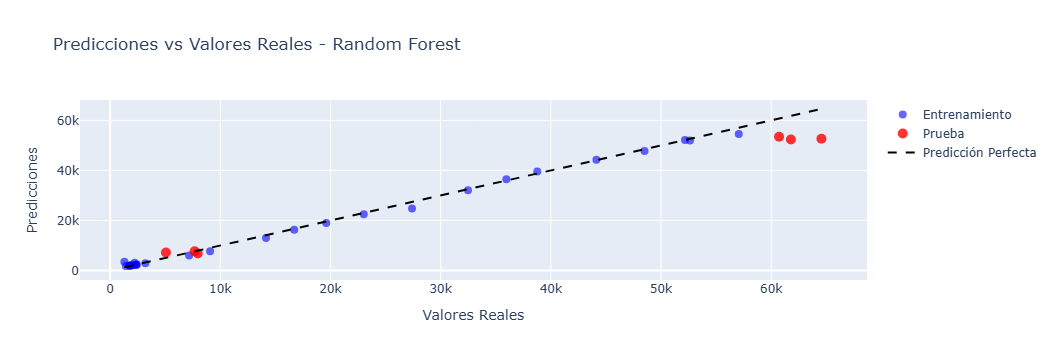

In [56]:
# ============================================================================
# VISUALIZACIÓN DE PREDICCIONES
# ============================================================================

print("\n" + "="*60)
print("📊 VISUALIZACIÓN DE PREDICCIONES")
print("="*60)

# Usar el índice temporal existente de df para visualización
fechas_completas = pd.to_datetime(df['fecha'])
fechas_train = fechas_completas.iloc[:len(y_train)]
fechas_test = fechas_completas.iloc[len(y_train):]

# Gráfico de predicciones vs reales
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Predicciones vs Reales (Completo)',
                   'Predicciones vs Reales (Test)',
                   'Residuos en Test',
                   'Distribución de Errores'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]]
)

# Gráfico 1: Serie completa
fig.add_trace(
    go.Scatter(x=fechas_train, y=y_train, mode='lines+markers',
               name='Real (Train)', line=dict(color='blue', width=2)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=fechas_train, y=best_pred_train, mode='lines',
               name='Pred RF (Train)', line=dict(color='green', width=2, dash='dash')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=fechas_test, y=y_test, mode='lines+markers',
               name='Real (Test)', line=dict(color='red', width=2)),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=fechas_test, y=best_pred_test, mode='lines+markers',
               name='Pred RF (Test)', line=dict(color='orange', width=3)),
    row=1, col=1
)

# Gráfico 2: Solo período de test
fig.add_trace(
    go.Scatter(x=fechas_test, y=y_test, mode='lines+markers',
               name='Real', line=dict(color='blue', width=3)),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=fechas_test, y=best_pred_test, mode='lines+markers',
               name='Predicción', line=dict(color='red', width=3)),
    row=1, col=2
)

# Gráfico 3: Residuos
residuos_test = y_test - best_pred_test
fig.add_trace(
    go.Scatter(x=fechas_test, y=residuos_test, mode='lines+markers',
               name='Residuos', line=dict(color='purple', width=2)),
    row=2, col=1
)
fig.add_hline(y=0, line=dict(color='black', dash='dash'), row=2, col=1)

# Gráfico 4: Distribución de errores
fig.add_trace(
    go.Histogram(x=residuos_test, name='Distribución Residuos',
                marker_color='lightcoral', opacity=0.7),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=True,
                  title_text="Análisis de Predicciones Random Forest")
fig.show()

# Gráfico de dispersión predicciones vs reales
fig_scatter = go.Figure()

# Datos de entrenamiento
fig_scatter.add_trace(go.Scatter(
    x=y_train, y=best_pred_train,
    mode='markers', name='Entrenamiento',
    marker=dict(color='blue', size=8, opacity=0.6)
))

# Datos de test
fig_scatter.add_trace(go.Scatter(
    x=y_test, y=best_pred_test,
    mode='markers', name='Prueba',
    marker=dict(color='red', size=10, opacity=0.8)
))

# Línea perfecta y=x
min_val = min(y.min(), min(best_pred_train.min(), best_pred_test.min()))
max_val = max(y.max(), max(best_pred_train.max(), best_pred_test.max()))
fig_scatter.add_trace(go.Scatter(
    x=[min_val, max_val], y=[min_val, max_val],
    mode='lines', name='Predicción Perfecta',
    line=dict(color='black', dash='dash', width=2)
))

fig_scatter.update_layout(
    title='Predicciones vs Valores Reales - Random Forest',
    xaxis_title='Valores Reales',
    yaxis_title='Predicciones',
    showlegend=True
)
fig_scatter.show()


🔄 VALIDACIÓN CRUZADA TEMPORAL
🔄 Ejecutando validación cruzada temporal...
   Fold 1: RMSE=7453.7, R²=0.5658
   Fold 2: RMSE=8525.0, R²=0.7228
   Fold 3: RMSE=5628.0, R²=0.9179
   Fold 4: RMSE=7165.5, R²=0.9130
   Fold 5: RMSE=6997.3, R²=0.9100

📊 Resultados de validación cruzada:
   RMSE promedio: 7153.9 ± 929.8
   R² promedio: 0.8059 ± 0.1410

🔍 ANÁLISIS DE INTERPRETABILIDAD CON SHAP
🔄 Calculando valores SHAP (puede tomar tiempo)...
✅ Valores SHAP calculados

📊 Importancia promedio SHAP:
   1. matricula_lag2: 10390.0547
   2. matricula_lag4: 9745.2690
   3. media_movil_4: 1008.0112
   4. año_numero: 993.1253
   5. poblacion_el_alto: 896.0446
   6. crecimiento_poblacional: 875.0812
   7. media_movil_8: 828.9415
   8. periodo_numero: 766.0229
   9. semestre_dummy: 726.4347
   10. pib_departamental_millones_bs: 491.6073


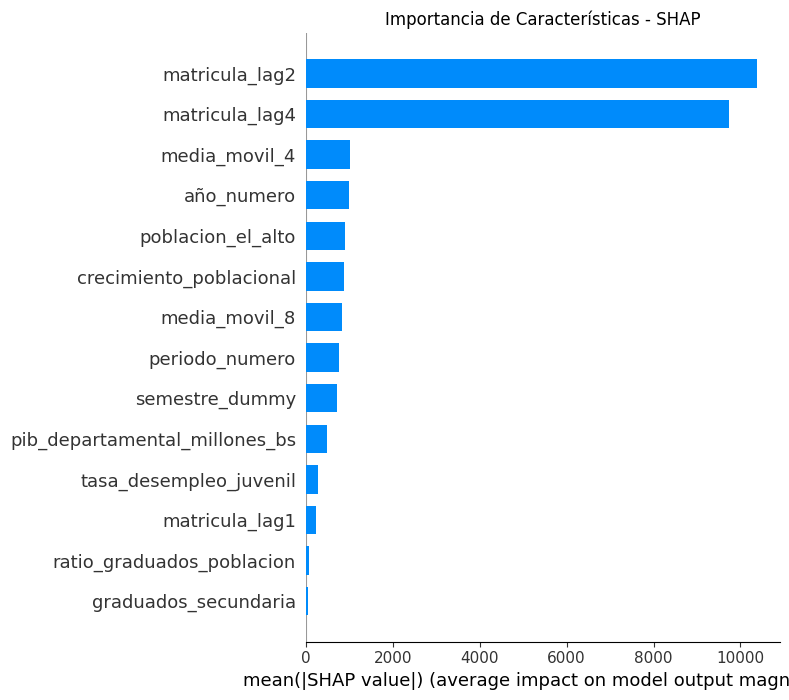


🚀 PROYECCIONES FUTURAS 2025-2030
📊 Características futuras generadas: (10, 14)

📊 Proyecciones Random Forest 2025-2030:
Período    Predicción RF  
------------------------------
2025-I           28,880
2025-II          27,054
2026-I           28,476
2026-II          27,127
2027-I           28,551
2027-II          27,240
2028-I           28,551
2028-II          27,206
2029-I           28,519
2029-II          27,168

📈 Análisis de crecimiento proyectado:
   Matrícula 2024: 7,954
   Matrícula 2030 (RF): 27,168
   Crecimiento total: 241.6%


In [57]:
# ============================================================================
# VALIDACIÓN CRUZADA TEMPORAL
# ============================================================================

print("\n" + "="*60)
print("🔄 VALIDACIÓN CRUZADA TEMPORAL")
print("="*60)

# Validación cruzada con TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_rmse = []
cv_scores_r2 = []

print("🔄 Ejecutando validación cruzada temporal...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
    # División
    X_cv_train, X_cv_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Entrenar modelo
    rf_cv = RandomForestRegressor(**best_rf.get_params())
    rf_cv.fit(X_cv_train, y_cv_train)

    # Predicciones
    pred_cv = rf_cv.predict(X_cv_val)

    # Métricas
    rmse_cv = np.sqrt(mean_squared_error(y_cv_val, pred_cv))
    r2_cv = r2_score(y_cv_val, pred_cv)

    cv_scores_rmse.append(rmse_cv)
    cv_scores_r2.append(r2_cv)

    print(f"   Fold {fold+1}: RMSE={rmse_cv:.1f}, R²={r2_cv:.4f}")

print(f"\n📊 Resultados de validación cruzada:")
print(f"   RMSE promedio: {np.mean(cv_scores_rmse):.1f} ± {np.std(cv_scores_rmse):.1f}")
print(f"   R² promedio: {np.mean(cv_scores_r2):.4f} ± {np.std(cv_scores_r2):.4f}")

# ============================================================================
# INTERPRETABILIDAD CON SHAP (si está disponible)
# ============================================================================

if SHAP_AVAILABLE:
    print("\n" + "="*60)
    print("🔍 ANÁLISIS DE INTERPRETABILIDAD CON SHAP")
    print("="*60)

    try:
        print("🔄 Calculando valores SHAP (puede tomar tiempo)...")

        # Crear explicador SHAP
        explainer = shap.TreeExplainer(best_rf)
        shap_values = explainer.shap_values(X_test_scaled)

        print("✅ Valores SHAP calculados")

        # Resumen de importancia SHAP
        print("\n📊 Importancia promedio SHAP:")
        shap_importance = np.abs(shap_values).mean(0)
        shap_indices = np.argsort(shap_importance)[::-1]

        for i in range(min(10, len(variables_disponibles))):
            idx = shap_indices[i]
            print(f"   {i+1}. {variables_disponibles[idx]}: {shap_importance[idx]:.4f}")

        # Visualizaciones SHAP
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
        plt.title('Importancia de Características - SHAP')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️  Error en análisis SHAP: {e}")

# ============================================================================
# PROYECCIONES FUTURAS 2025-2030
# ============================================================================

print("\n" + "="*60)
print("🚀 PROYECCIONES FUTURAS 2025-2030")
print("="*60)

# Función para generar características futuras
def generar_caracteristicas_futuras(ultimo_registro, n_periodos=10):
    """
    Genera características para períodos futuros basándose en tendencias
    """
    caracteristicas_futuras = []

    for i in range(n_periodos):
        # Año y semestre
        año_futuro = 2025 + i // 2
        semestre_futuro = 'I' if i % 2 == 0 else 'II'

        # Características temporales
        año_numero = año_futuro - 2010
        semestre_dummy = 1 if semestre_futuro == 'I' else 0
        periodo_numero = ultimo_registro['periodo_numero'] + i + 1

        # Proyecciones de variables externas (tendencias simples)
        años_proyeccion = i / 2

        pib_proyectado = (ultimo_registro['pib_departamental_millones_bs'] +
                         años_proyeccion * 200)  # Crecimiento histórico promedio

        poblacion_proyectada = (ultimo_registro['poblacion_el_alto'] +
                               años_proyeccion * 25000)  # Crecimiento demográfico

        graduados_proyectados = (ultimo_registro['graduados_secundaria'] +
                                años_proyeccion * 300)  # Crecimiento educativo

        desempleo_proyectado = max(8, ultimo_registro['tasa_desempleo_juvenil'] -
                                  años_proyeccion * 0.1)  # Mejora gradual

        # Variables derivadas
        crecimiento_pob = 0.025  # 2.5% anual promedio
        ratio_graduados = graduados_proyectados / poblacion_proyectada * 1000

        # Para lags y medias móviles, usaremos proyecciones recursivas
        # Por simplicidad, mantendremos valores del último período
        matricula_lag1 = ultimo_registro['matricula_total'] if i == 0 else None
        matricula_lag2 = ultimo_registro.get('matricula_lag1', ultimo_registro['matricula_total'])
        matricula_lag4 = ultimo_registro.get('matricula_lag2', ultimo_registro['matricula_total'])
        media_movil_4 = ultimo_registro['matricula_total']
        media_movil_8 = ultimo_registro['matricula_total']

        caracteristicas = {
            'año_numero': año_numero,
            'semestre_dummy': semestre_dummy,
            'periodo_numero': periodo_numero,
            'matricula_lag1': matricula_lag1,
            'matricula_lag2': matricula_lag2,
            'matricula_lag4': matricula_lag4,
            'media_movil_4': media_movil_4,
            'media_movil_8': media_movil_8,
            'pib_departamental_millones_bs': pib_proyectado,
            'poblacion_el_alto': poblacion_proyectada,
            'graduados_secundaria': graduados_proyectados,
            'tasa_desempleo_juvenil': desempleo_proyectado,
            'crecimiento_poblacional': crecimiento_pob,
            'ratio_graduados_poblacion': ratio_graduados
        }

        # Filtrar solo las características disponibles
        caracteristicas_filtradas = {k: v for k, v in caracteristicas.items()
                                   if k in variables_disponibles}

        caracteristicas_futuras.append(caracteristicas_filtradas)

    return pd.DataFrame(caracteristicas_futuras)

# Generar características futuras
ultimo_registro = df.iloc[-1].to_dict()
X_futuro = generar_caracteristicas_futuras(ultimo_registro, n_periodos=10)

print(f"📊 Características futuras generadas: {X_futuro.shape}")

# Normalizar características futuras
X_futuro_scaled = scaler.transform(X_futuro)
X_futuro_scaled = pd.DataFrame(X_futuro_scaled, columns=X_futuro.columns)

# Realizar proyecciones
proyecciones_rf = best_rf.predict(X_futuro_scaled)

# Crear DataFrame de proyecciones
fechas_futuras = []
for i in range(10):
    año = 2025 + i // 2
    mes = 3 if i % 2 == 0 else 8
    fechas_futuras.append(pd.Timestamp(año, mes, 1))

df_proyecciones_rf = pd.DataFrame({
    'fecha': fechas_futuras,
    'prediccion_rf': proyecciones_rf,
    'año': [f.year for f in fechas_futuras],
    'semestre': ['I' if f.month == 3 else 'II' for f in fechas_futuras],
    'periodo': [f"{f.year}-{('I' if f.month == 3 else 'II')}" for f in fechas_futuras]
})

print(f"\n📊 Proyecciones Random Forest 2025-2030:")
print(f"{'Período':<10} {'Predicción RF':<15}")
print("-" * 30)

for _, row in df_proyecciones_rf.iterrows():
    print(f"{row['periodo']:<10} {row['prediccion_rf']:>12,.0f}")

# Análisis de crecimiento
matricula_2024 = y.iloc[-1]
matricula_2030_rf = df_proyecciones_rf.iloc[-1]['prediccion_rf']
crecimiento_total_rf = ((matricula_2030_rf / matricula_2024) - 1) * 100

print(f"\n📈 Análisis de crecimiento proyectado:")
print(f"   Matrícula 2024: {matricula_2024:,.0f}")
print(f"   Matrícula 2030 (RF): {matricula_2030_rf:,.0f}")
print(f"   Crecimiento total: {crecimiento_total_rf:.1f}%")


📊 VISUALIZACIÓN FINAL


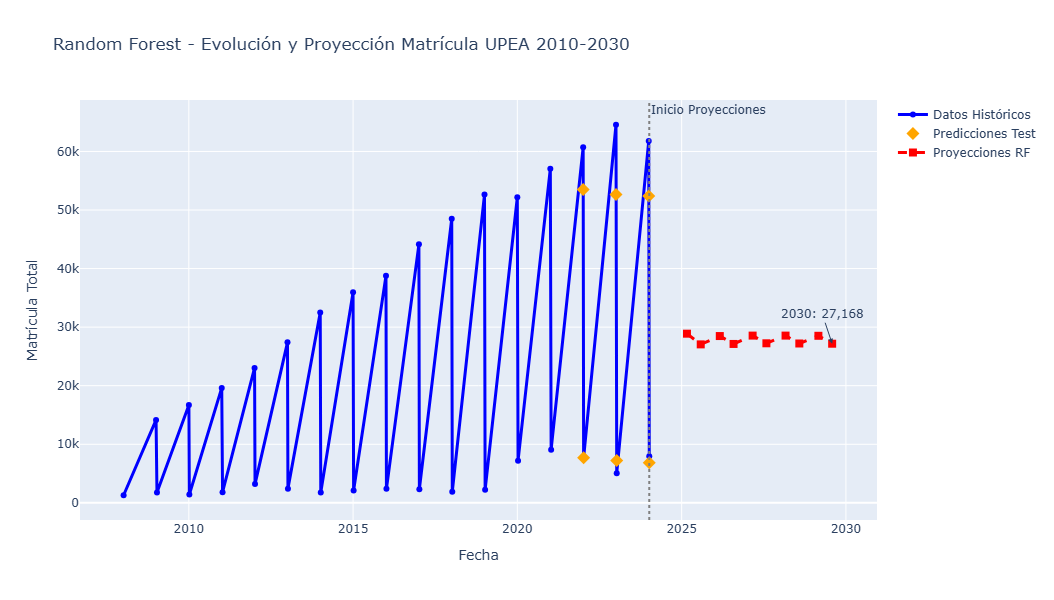

In [58]:
# ============================================================================
# VISUALIZACIÓN FINAL
# ============================================================================

print("\n" + "="*60)
print("📊 VISUALIZACIÓN FINAL")
print("="*60)

# Gráfico completo histórico + proyecciones
fig_final = go.Figure()

# Datos históricos
# Usar directamente la columna 'fecha' del DataFrame para los datos históricos
fechas_historicas = pd.to_datetime(df['fecha'])
fig_final.add_trace(go.Scatter(
    x=fechas_historicas,
    y=df['matricula_total'],
    mode='lines+markers',
    name='Datos Históricos',
    line=dict(color='blue', width=3),
    marker=dict(size=6)
))

# Predicciones en test
fig_final.add_trace(go.Scatter(
    x=fechas_test,
    y=best_pred_test,
    mode='markers',
    name='Predicciones Test',
    marker=dict(color='orange', size=10, symbol='diamond')
))

# Proyecciones futuras
fig_final.add_trace(go.Scatter(
    x=df_proyecciones_rf['fecha'],
    y=df_proyecciones_rf['prediccion_rf'],
    mode='lines+markers',
    name='Proyecciones RF',
    line=dict(color='red', width=3, dash='dash'),
    marker=dict(size=8, symbol='square')
))

# Línea separadora - Use the index of the last historical data point
# Asegurarse de que el x sea una fecha o un índice válido para la línea vertical
# Usaremos el último valor de fechas_historicas para la posición x, convertido a su valor numérico (timestamp)
fig_final.add_vline(x=fechas_historicas.iloc[-1].timestamp() * 1000,
                   line=dict(color="gray", width=2, dash="dot"),
                   annotation_text="Inicio Proyecciones")

fig_final.update_layout(
    title='Random Forest - Evolución y Proyección Matrícula UPEA 2010-2030',
    xaxis_title='Fecha',
    yaxis_title='Matrícula Total',
    height=600,
    showlegend=True
)

# Anotación final
fig_final.add_annotation(
    x=df_proyecciones_rf['fecha'].iloc[-1],
    y=df_proyecciones_rf['prediccion_rf'].iloc[-1],
    text=f"2030: {df_proyecciones_rf['prediccion_rf'].iloc[-1]:,.0f}",
    showarrow=True,
    arrowhead=2
)

fig_final.show()


In [59]:
# ============================================================================
# EXPORTAR RESULTADOS
# ============================================================================

print("\n" + "="*60)
print("💾 EXPORTANDO RESULTADOS")
print("="*60)

# Guardar modelos
joblib.dump(best_rf, 'modelo_rf_optimizado.pkl')
joblib.dump(tesis_rf, 'modelo_rf_tesis.pkl')
joblib.dump(scaler, 'scaler_rf.pkl')

# Guardar proyecciones
df_proyecciones_rf.to_csv('proyecciones_rf_2025_2030.csv', index=False)
df_proyecciones_rf.to_pickle('proyecciones_rf_2025_2030.pkl')

# Guardar métricas
metricas_rf = {
    'modelo_optimizado': {
        'parametros': best_rf.get_params(),
        'rmse_test': float(best_rmse_test),
        'mae_test': float(best_mae_test),
        'mape_test': float(best_mape_test),
        'r2_test': float(best_r2_test),
        'cv_rmse_mean': float(np.mean(cv_scores_rmse)),
        'cv_rmse_std': float(np.std(cv_scores_rmse)),
        'cv_r2_mean': float(np.mean(cv_scores_r2)),
        'cv_r2_std': float(np.std(cv_scores_r2))
    },
    'modelo_tesis': {
        'parametros': {'n_estimators': 500, 'max_depth': 15},
        'rmse_test': float(tesis_rmse_test),
        'mae_test': float(tesis_mae_test),
        'mape_test': float(tesis_mape_test),
        'r2_test': float(tesis_r2_test)
    },
    'importancia_caracteristicas': dict(zip(variables_disponibles, importancias.tolist())),
    'proyeccion_2030': float(matricula_2030_rf),
    'crecimiento_proyectado': float(crecimiento_total_rf)
}

# Guardar en JSON
import json
with open('metricas_rf.json', 'w') as f:
    json.dump(metricas_rf, f, indent=4, default=str)

print("✅ Archivos exportados:")
print("   - modelo_rf_optimizado.pkl")
print("   - modelo_rf_tesis.pkl")
print("   - scaler_rf.pkl")
print("   - proyecciones_rf_2025_2030.csv/pkl")
print("   - metricas_rf.json")

# ============================================================================
# RESUMEN FINAL DEL MODELO RANDOM FOREST
# ============================================================================

print("\n" + "="*60)
print("📋 RESUMEN FINAL DEL MODELO RANDOM FOREST")
print("="*60)

print(f"🌳 Modelo Random Forest optimizado:")
print(f"   Número de árboles: {best_rf.n_estimators}")
print(f"   Profundidad máxima: {best_rf.max_depth}")
print(f"   Características usadas: {len(variables_disponibles)}")

print(f"\n📊 Métricas finales (conjunto de prueba):")
print(f"   RMSE: {best_rmse_test:.1f} estudiantes")
print(f"   MAPE: {best_mape_test:.2f}%")
print(f"   R²: {best_r2_test:.4f}")

print(f"\n🔍 Top 3 características más importantes:")
for i in range(min(3, len(variables_disponibles))):
    idx = indices[i]
    print(f"   {i+1}. {variables_disponibles[idx]}: {importancias[idx]:.4f}")

print(f"\n🚀 Proyecciones clave:")
print(f"   2025-I: {df_proyecciones_rf[df_proyecciones_rf['periodo']=='2025-I']['prediccion_rf'].iloc[0]:,.0f}")
print(f"   2030-I: {df_proyecciones_rf.iloc[-1]['prediccion_rf']:,.0f}")
print(f"   Crecimiento 2024-2030: {crecimiento_total_rf:.1f}%")

print(f"\n✅ Random Forest listo para ensemble")


💾 EXPORTANDO RESULTADOS
✅ Archivos exportados:
   - modelo_rf_optimizado.pkl
   - modelo_rf_tesis.pkl
   - scaler_rf.pkl
   - proyecciones_rf_2025_2030.csv/pkl
   - metricas_rf.json

📋 RESUMEN FINAL DEL MODELO RANDOM FOREST
🌳 Modelo Random Forest optimizado:
   Número de árboles: 300
   Profundidad máxima: 10
   Características usadas: 14

📊 Métricas finales (conjunto de prueba):
   RMSE: 6934.5 estudiantes
   MAPE: 17.06%
   R²: 0.9376

🔍 Top 3 características más importantes:
   1. matricula_lag2: 0.4356
   2. matricula_lag4: 0.4142
   3. crecimiento_poblacional: 0.0415

🚀 Proyecciones clave:
   2025-I: 28,880
   2030-I: 27,168
   Crecimiento 2024-2030: 241.6%

✅ Random Forest listo para ensemble
